<a href="https://colab.research.google.com/github/armeros/DC_ML/blob/main/Kaggle/Kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, scipy, seaborn as sns, xgboost as xgb, itertools
from math import sqrt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, StratifiedKFold, TimeSeriesSplit, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# **Train and Test Data**

In [ ]:
taxi_train, taxi_test = pd.read_csv("taxi_train_chapter_4.csv"), pd.read_csv("taxi_test_chapter_4.csv")
taxi_train.columns.to_list(), taxi_test.columns.to_list()

(['id',
  'fare_amount',
  'pickup_datetime',
  'pickup_longitude',
  'pickup_latitude',
  'dropoff_longitude',
  'dropoff_latitude',
  'passenger_count'],
 ['id',
  'pickup_datetime',
  'pickup_longitude',
  'pickup_latitude',
  'dropoff_longitude',
  'dropoff_latitude',
  'passenger_count'])

# **Define Problem Type**

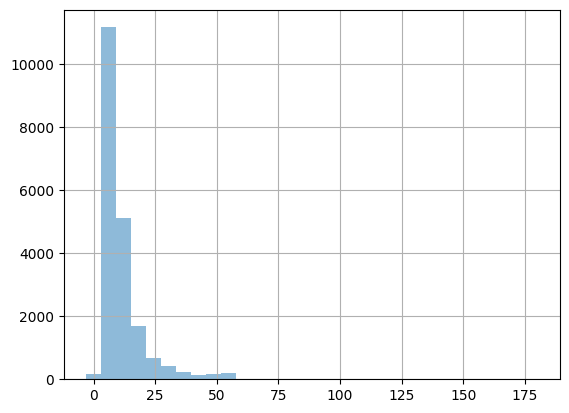

In [ ]:
taxi_train['fare_amount'].hist(bins=30, alpha=0.5)
plt.show()

From the image `fare_amount` is a continuous variable so it is a regression problem.

## **Train the model**

In [ ]:
X_train = taxi_train[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude','dropoff_latitude','passenger_count']]
y_train = taxi_train['fare_amount']

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

## **Predict the test set**

In [ ]:
X_test = taxi_test[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude','dropoff_latitude','passenger_count']]

# Make predictions
taxi_test['fare_amount'] = lr.predict(X_test)

## **Prepare submission file**

In [ ]:
taxi_submission = taxi_test[['id', 'fare_amount']]
display(taxi_submission.head())
taxi_submission.to_csv('first_sub.csv', index=False)

,id,fare_amount
0,0,11.235023
1,1,11.236369
2,2,11.235279
3,3,11.234863
4,4,11.234457


### ***Exercise: Train a simple model***

As you determined, you are dealing with a regression problem. So, now you're ready to build a model for a subsequent submission. But now, instead of building the simplest Linear Regression model, let's build an out-of-box Random Forest model.

You will use the **`RandomForestRegressor`** class from the **`scikit-learn`** library.

Your objective is to train a Random Forest model with default parameters on the `"store"` and `"item"` features.

#### ***Instructions***

- Read the train data using `pandas`.
- Create a Random Forest object.
- Train the Random Forest model on the `"store"` and `"item"` features with `"sales"` as a target.

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

train = pd.read_csv("demand_forecasting_train_1_month.csv")
test = pd.read_csv('demand_forecasting_test.csv')

# Create a Random Forest object
rf = RandomForestRegressor()

# Train a model
rf.fit(X=train[['store', 'item']], y=train['sales'])

# Get predictions for the test set
test['sales'] = rf.predict(test[['store', 'item']])

# Write test predictions using the sample_submission format
test[['id', 'sales']].to_csv('kaggle_submission.csv', index=False)

# **Overfitting**

### ***Exercise: Train XGBoost models***

Every Machine Learning method could potentially overfit. You will see it on this example with XGBoost. Again, you are working with the Store Item Demand Forecasting Challenge. The `train` DataFrame is available in your workspace.

Firstly, let's train multiple XGBoost models with different sets of hyperparameters using XGBoost's learning API. The single hyperparameter you will change is:

- `max_depth` - maximum depth of a tree. Increasing this value will make the model more complex and more likely to overfit.

#### ***Instructions***


1. Set the maximum depth to 2. Then hit Submit Answer button to train the first model.
2. Now, set the maximum depth to 8. Then hit Submit Answer button to train the second model.
3. Finally, set the maximum depth to 15. Then hit Submit Answer button to train the third model.


In [ ]:
import xgboost as xgb

# Create DMatrix on train data
dtrain = xgb.DMatrix(data=train[['store', 'item']],
                     label=train['sales'])

# Define xgboost parameters
params = {'objective': 'reg:squarederror',
          'max_depth': 2,
          'verbosity': 0}

# Train xgboost model
xg_depth_2 = xgb.train(params=params, dtrain=dtrain)

# Define xgboost parameters
params = {'objective': 'reg:squarederror',
          'max_depth': 8,
          'verbosity': 0}

# Train xgboost model
xg_depth_8 = xgb.train(params=params, dtrain=dtrain)

# Define xgboost parameters
params = {'objective': 'reg:squarederror',
          'max_depth': 15,
          'verbosity': 0}

# Train xgboost model
xg_depth_15 = xgb.train(params=params, dtrain=dtrain)

### ***Exercise: Explore overfitting XGBoost***

Having trained 3 XGBoost models with different maximum depths, you will now evaluate their quality. For this purpose, you will measure the quality of each model on both the train data and the test data. As you know by now, the train data is the data models have been trained on. The test data is the next month sales data that models have never seen before.

The goal of this exercise is to determine whether any of the models trained is overfitting. To measure the quality of the models you will use Mean Squared Error (MSE). It's available in sklearn.metrics as mean_squared_error() function that takes two arguments: true values and predicted values.

#### ***Instructions***

- Make predictions for each model on both the train and test data.
- Calculate the MSE between the true values and your predictions for both the train and test data.

In [ ]:
from sklearn.metrics import mean_squared_error

dtrain = xgb.DMatrix(data=train[['store', 'item']])
dtest = xgb.DMatrix(data=test[['store', 'item']])

# For each of 3 trained models
for model in [xg_depth_2, xg_depth_8, xg_depth_15]:
    # Make predictions
    train_pred = model.predict(dtrain)
    test_pred = model.predict(dtest)

    # Calculate metrics
    mse_train = mean_squared_error(train['sales'], train_pred)
    mse_test = mean_squared_error(test['sales'], test_pred)
    print('MSE Train: {:.3f}. MSE Test: {:.3f}'.format(mse_train, mse_test))

MSE Train: 329.507. MSE Test: 248.113
MSE Train: 111.333. MSE Test: 29.873
MSE Train: 81.887. MSE Test: 0.456


(จริงๆ ต้องเป็น model ที่ 3 ที่ MSE Train ลดลงแต่ MSE Test เพิ่มขึ้น แต่ไฟล์ข้อมูล test ที่มี มันไม่มีคอลัมน์ `sales` ของจริงมาให้)

# **Initial EDA**

- **`df.shape()`**
- **`df.columns.to_list()`**
- **`df['target column'].value_counts()`** ⟹ Useful for checking class imbalance
- **`df.describe()`**

## **Visialization EDA**

- **plot = `df.groupby('target column', as_index=False)['other column'].median()`**


```
fig = plt.figure(figsize=(7, 5))
plt.bar(plot['target column'], plot['other column'])
```



### ***Exercise: EDA statistics***

You'll work with New York City taxi fare prediction data. You'll start with finding some basic statistics about the data. Then you'll move forward to plot some dependencies and generate hypotheses on them.

#### ***Instructions***

* Find the shapes of the train and test data.
* Look at the head of the train data.


In [ ]:
train, test = pd.read_csv('taxi_train_chapter_4.csv'), pd.read_csv('taxi_test_chapter_4.csv')

# Shapes of train and test data
print('Train shape:', train.shape)
print('Test shape:', test.shape)

# Train head()
display(train.head())

# Describe the target variable
display(train.fare_amount.describe())

# Train distribution of passengers within rides
display(train.passenger_count.value_counts())

Train shape: (20000, 8)
Test shape: (9914, 7)


,id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,0,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,1,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,3,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,4,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


,fare_amount
count,20000.000000
mean,11.303321
std,9.541637
min,-3.000000
25%,6.000000
50%,8.500000
75%,12.500000
max,180.000000


,count
passenger_count,
1,13999
2,2912
5,1327
3,860
4,420
6,407
0,75


### ***Exercise: EDA plots I***

After generating a couple of basic statistics, it's time to come up with and validate some ideas about the data dependencies.

To begin with, let's make a scatterplot plotting the relationship between the fare amount and the distance of the ride. Intuitively, the longer the ride, the higher its price.

To get the distance in kilometers between two geo-coordinates, you will use Haversine distance. Its calculation is available with the `haversine_distance()` function defined for you. The function expects `train` DataFrame as input.

#### ***Instructions***

- Create a new variable `"distance_km"` as Haversine distance between pickup and dropoff points.
- Plot a scatterplot with `"fare_amount"` on the x axis and `"distance_km"` on the y axis. To draw a scatterplot use matplotlib **`scatter()`** method.
- Set a limit on a ride distance to be between 0 and 50 kilometers to avoid plotting outliers.


In [ ]:
def haversine_distance(train):

    data = [train]
    lat1, long1, lat2, long2 = 'pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude'

    for i in data:
        R = 6371  #radius of earth in kilometers
        #R = 3959 #radius of earth in miles
        phi1 = np.radians(i[lat1])
        phi2 = np.radians(i[lat2])

        delta_phi = np.radians(i[lat2]-i[lat1])
        delta_lambda = np.radians(i[long2]-i[long1])

        #a = sin²((φB - φA)/2) + cos φA . cos φB . sin²((λB - λA)/2)
        a = np.sin(delta_phi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2.0) ** 2

        #c = 2 * atan2( √a, √(1−a) )
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

        #d = R*c
        d = (R * c) #in kilometers

    return d

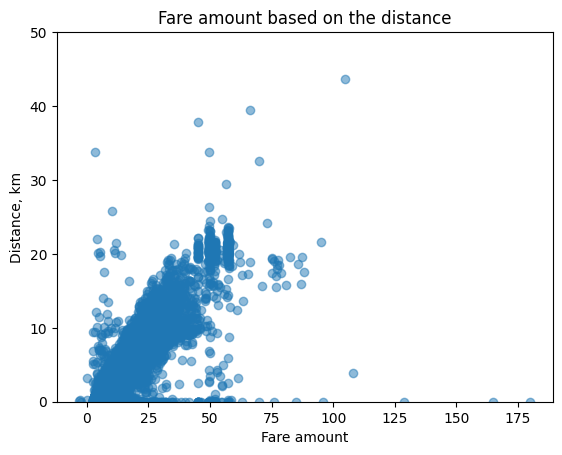

In [ ]:
# Calculate the ride distance
train['distance_km'] = haversine_distance(train)

# Draw a scatterplot
plt.scatter(x=train['fare_amount'], y=train['distance_km'], alpha=0.5)
plt.xlabel('Fare amount')
plt.ylabel('Distance, km')
plt.title('Fare amount based on the distance')

# Limit on the distance
plt.ylim(0, 50)
plt.show()

### ***Exercise: EDA plots II***

Another idea that comes to mind is that the price of a ride could change during the day.

Your goal is to plot the median fare amount for each hour of the day as a simple line plot.

#### ***Instructions***

- Group `train` DataFrame by `"hour"` and calculate the median for the `"fare_amount"` column.
- Using `hour_price` DataFrame obtained, plot a line with `"hour"` on the x axis and `"fare_amount"` on the y axis.

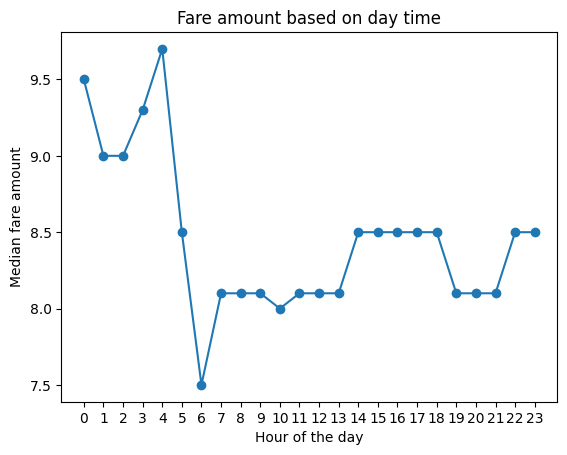

In [ ]:
# Create hour feature
train['pickup_datetime'] = pd.to_datetime(train['pickup_datetime'])
train['hour'] = train['pickup_datetime'].dt.hour

# Find median fare_amount for each hour
hour_price = train.groupby('hour', as_index=False)['fare_amount'].median()

# Plot the line plot
plt.plot(hour_price["hour"], hour_price["fare_amount"], marker='o')
plt.xlabel('Hour of the day')
plt.ylabel('Median fare amount')
plt.title('Fare amount based on day time')
plt.xticks(range(24))
plt.show()

 We see that prices are a bit higher during the night. It is a good indicator that we should include the `"hour"` feature in the final model, or at least add a binary feature `"is_night"`. Next lesson is to learn how to check whether new features are useful for the model or not!

 # **Hold out set**

 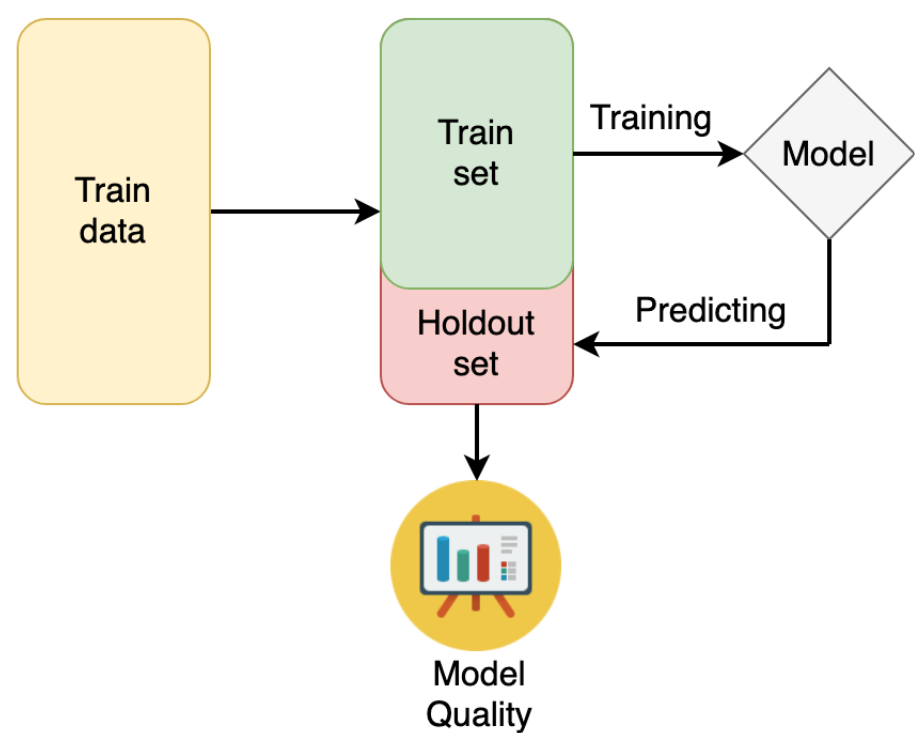

# **K-Fold Cross Validation**

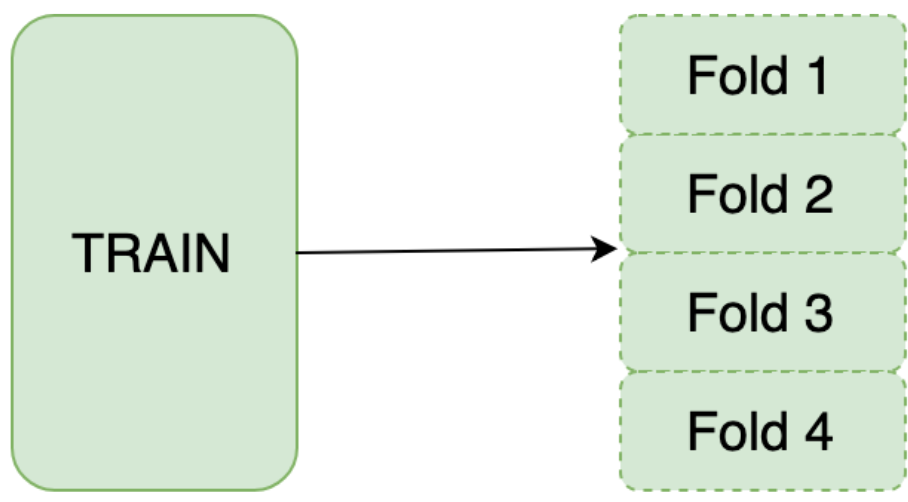

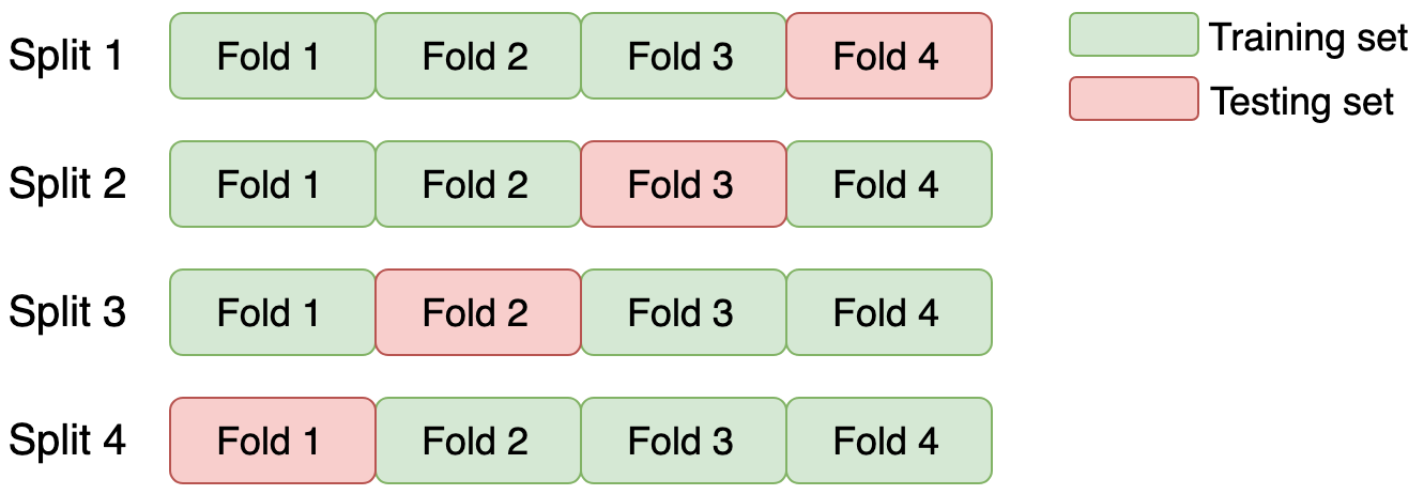

In [ ]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=123)

# Loop through each cross-validation split
for train_index, test_index in kf.split(train):
    cv_train, cv_test = train.iloc[train_index], train.iloc[test_index]

# **Stratified K-Fold**

* Preserver the percentage of samples for each class of this variable

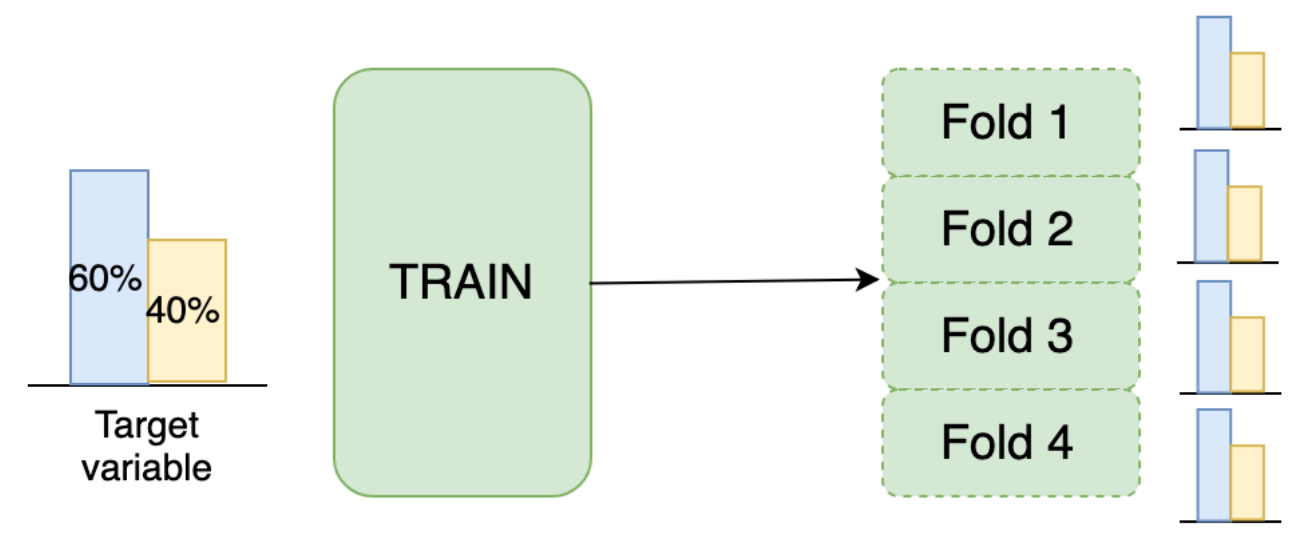

* Each fold has the same class distribution as in the initial data
* Useful when we have classification problem
  * with high class imbalance
  * small dataset

In [ ]:
from sklearn.model_selection import StratifiedKFold

str_kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

for train_index, test_index in str_kf.split(train, train['target']):
    cv_train, cv_test = train.iloc[train_index], train.iloc[test_index]

### ***Exercise: K-fold cross-validation***

You will start by getting hands-on experience in the most commonly used K-fold cross-validation.

The data you'll be working with is from the **"Two sigma connect: rental listing inquiries"** Kaggle competition. The competition problem is a multi-class classification of the rental listings into 3 classes:
- low interest
- medium interest
- high interest.

You need to implement a K-fold validation strategy and look at the sizes of each fold obtained.

#### ***Instructions***

- Create a **`KFold`** object with 3 folds.
- Loop over each split using the `kf` object.
- For each split select training and testing folds using `train_index` and `test_index`.


In [ ]:
from sklearn.model_selection import KFold

train = pd.read_json("train.json")

# Create a KFold object
kf = KFold(n_splits=3, shuffle=True, random_state=123)

# Loop through each split
fold = 0
for train_index, test_index in kf.split(train):
    # Obtain training and testing folds
    cv_train, cv_test = train.iloc[train_index], train.iloc[test_index]
    print('Fold: {}'.format(fold))
    print('CV train shape: {}'.format(cv_train.shape))
    print('Medium interest listings in CV train: {}\n'.format(sum(cv_train["interest_level"] == 'medium')))
    fold += 1

Fold: 0
CV train shape: (32901, 15)
Medium interest listings in CV train: 7475

Fold: 1
CV train shape: (32901, 15)
Medium interest listings in CV train: 7499

Fold: 2
CV train shape: (32902, 15)
Medium interest listings in CV train: 7484



We've just splitted the train data into 3 equal folds. However, if we look at the number of medium-interest listings, it's varying from 7475 to 7499 from one fold to another. To make them uniform among the folds, let's use Stratified K-fold.

### ***Exercise: Stratified K-fold***

As you've just noticed, you have a pretty different target variable distribution among the folds due to the random splits. It's not crucial for this particular competition, but could be an issue for the classification competitions with the highly imbalanced target variable.

To overcome this, let's implement the stratified K-fold strategy with the stratification on the target variable.

#### ***Instructions***

- Create a `StratifiedKFold` object with 3 folds and shuffling.
Loop over each split using `str_kf` object. Stratification is based on the `"interest_level"` column.

- For each split select training and testing folds using `train_index` and `test_index`.


In [ ]:
from sklearn.model_selection import StratifiedKFold

# Create a StratifiedKFold object
str_kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

# Loop through each split
fold = 0
for train_index, test_index in str_kf.split(train, train['interest_level']):
    # Obtain training and testing folds
    cv_train, cv_test = train.iloc[train_index], train.iloc[test_index]
    print('Fold: {}'.format(fold))
    print('CV train shape: {}'.format(cv_train.shape))
    print('Medium interest listings in CV train: {}\n'.format(sum(cv_train['interest_level'] == 'medium')))
    fold += 1

Fold: 0
CV train shape: (32901, 15)
Medium interest listings in CV train: 7486

Fold: 1
CV train shape: (32901, 15)
Medium interest listings in CV train: 7486

Fold: 2
CV train shape: (32902, 15)
Medium interest listings in CV train: 7486



Now you see that both size and target distribution are the same among the folds. The general rule is to ***prefer Stratified K-Fold over usual K-Fold*** in any classification problem.

# **Data Leakage**

1. Leak in **features**: Using the data that will not be available in the real setting.
  - e.g. predicting sales in $ while having exactly the same sales in £.
2. Leak in **validation strategy**: validation strategy differs from the real-world situation
  - e.g. time series data cannot use random split
  


## **Time K-Fold Cross Validation**

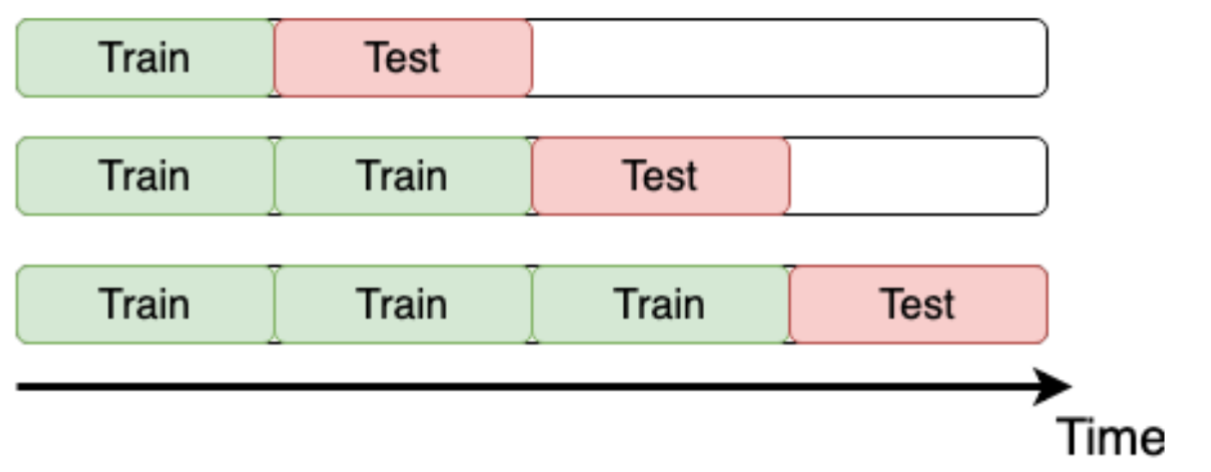

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

time_kfold = TimeSeriesSplit(n_splits=5)

# Sort date
train = train.sort_values('date')

for train_index, test_index in time_kfold.split(train):
    cv_train, cv_test = train.iloc[train_index], train.iloc[test_index]

## **Validation Pipeline**

In [ ]:
fold_metrics = []

for train_index, test_index in CV_STRATEGY.split(train): # CV__STRATEGY e.g. KFold, StrKFold
    cv_train, cv_test = train.iloc[train_index], train.iloc[test_index]
    model.fit(cv_train)
    predictions = model.predict(cv_test)
    metric = evaluate(cv_test, predictions)
    fold_metrics.append(metric)

mean_score = np.mean(fold_metrics) # can +, - np.std(fold_metrics)

### ***Exercise: Time K-fold***

Remember the "Store Item Demand Forecasting Challenge" where you are given store-item sales data, and have to predict future sales?

It's a competition with time series data. So, time K-fold cross-validation should be applied. Your goal is to create this cross-validation strategy and make sure that it works as expected.

#### ***Instructions***

- Create a **`TimeSeriesSplit`** object with 3 splits.
- Sort the `train` data by `"date"` column to apply time K-fold.
- Loop over each time split using `time_kfold` object.
- For each split select training and testing folds using `train_index` and `test_index`.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

train = pd.read_csv("demand_forecasting_train_1_month.csv")

# Create TimeSeriesSplit object
time_kfold = TimeSeriesSplit(n_splits=3)

# Sort train data by date
train = train.sort_values("date")

# Iterate through each split
fold = 0
for train_index, test_index in time_kfold.split(train):
    cv_train, cv_test = train.iloc[train_index], train.iloc[test_index]

    print('Fold :', fold)
    print('Train date range: from {} to {}'.format(cv_train.date.min(), cv_train.date.max()))
    print('Test date range: from {} to {}\n'.format(cv_test.date.min(), cv_test.date.max()))
    fold += 1

Fold : 0
Train date range: from 2017-12-01 to 2017-12-08
Test date range: from 2017-12-08 to 2017-12-16

Fold : 1
Train date range: from 2017-12-01 to 2017-12-16
Test date range: from 2017-12-16 to 2017-12-24

Fold : 2
Train date range: from 2017-12-01 to 2017-12-24
Test date range: from 2017-12-24 to 2017-12-31



Training only on the past data and predicting the future.


### ***Exercise: Overall validation score***

Now it's time to get the actual model performance using cross-validation! How does our store item demand prediction model perform?

Your task is to take the Mean Squared Error (MSE) for each fold separately, and then combine these results into a single number.

For simplicity, you're given `get_fold_mse()` function that for each cross-validation split fits a Random Forest model and returns a list of MSE scores by fold. `get_fold_mse()` accepts two arguments: `train` and `TimeSeriesSplit` object.

##### ***Instruction***

- Create time 3-fold cross-validation.
- Print the mean of MSE scores by folds.

In [ ]:
def get_fold_mse(train, kf):
    mse_scores = []

    for train_index, test_index in kf.split(train):
        fold_train, fold_test = train.loc[train_index], train.loc[test_index]

        # Fit the data and make predictions
        # Create a Random Forest object
        rf = RandomForestRegressor(n_estimators=10, random_state=123)

        # Train a model
        rf.fit(X=fold_train[['store', 'item']], y=fold_train['sales'])

        # Get predictions for the test set
        pred = rf.predict(fold_test[['store', 'item']])

        fold_score = round(mean_squared_error(fold_test['sales'], pred), 5)
        mse_scores.append(fold_score)

    return mse_scores

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Sort train data by date
train = train.sort_values('date')

# Initialize 3-fold time cross-validation
kf = TimeSeriesSplit(n_splits=3)

# Get MSE scores for each cross-validation split
mse_scores = get_fold_mse(train, kf)

print('Mean validation MSE: {:.5f}'.format(np.mean(mse_scores)))
print('MSE by fold: {}'.format(mse_scores))
print('Overall validation MSE: {:.5f}'.format(np.mean(mse_scores) + np.std(mse_scores)))

Mean validation MSE: 955.49186
MSE by fold: [890.30336, 961.65797, 1014.51424]
Overall validation MSE: 1006.38784


Now, you know different validation strategies as well as how to use them to obtain overall model performance.

# **Feature Engineering**

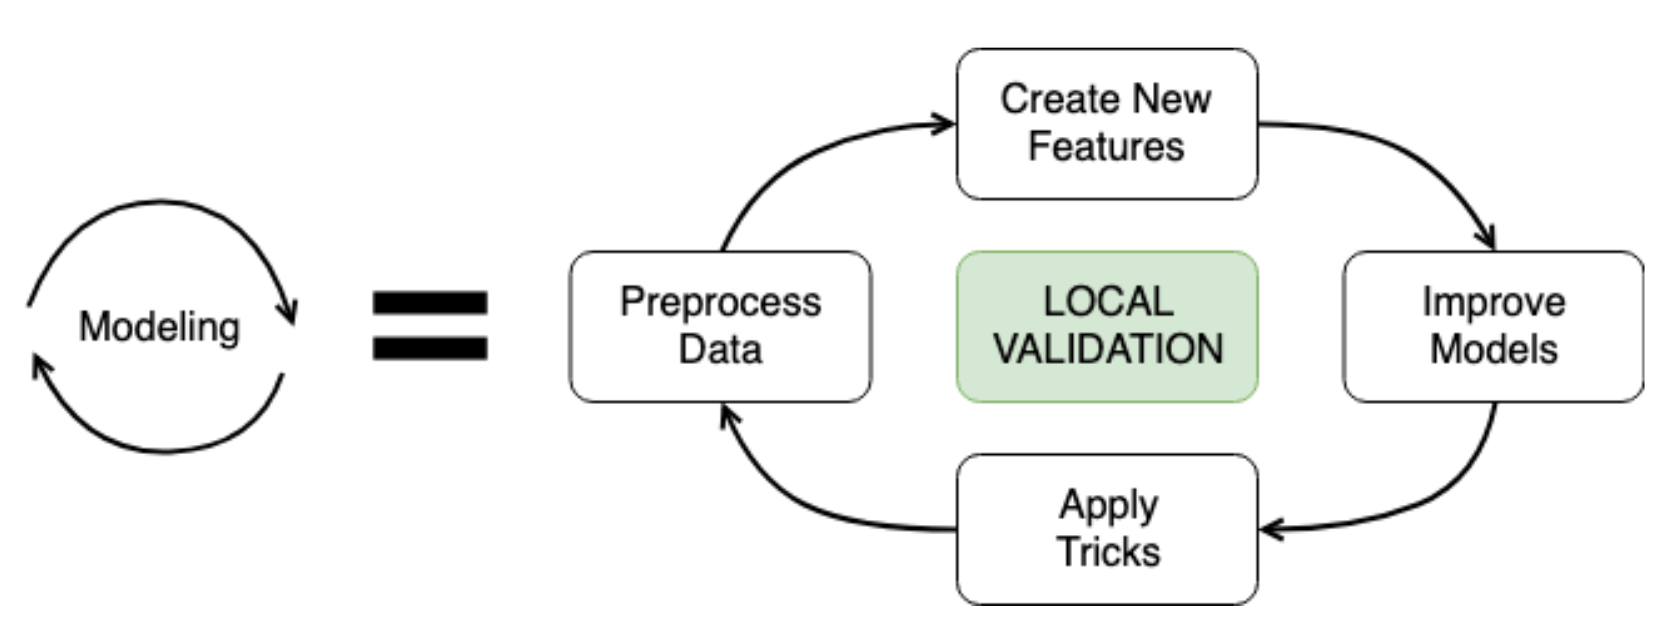

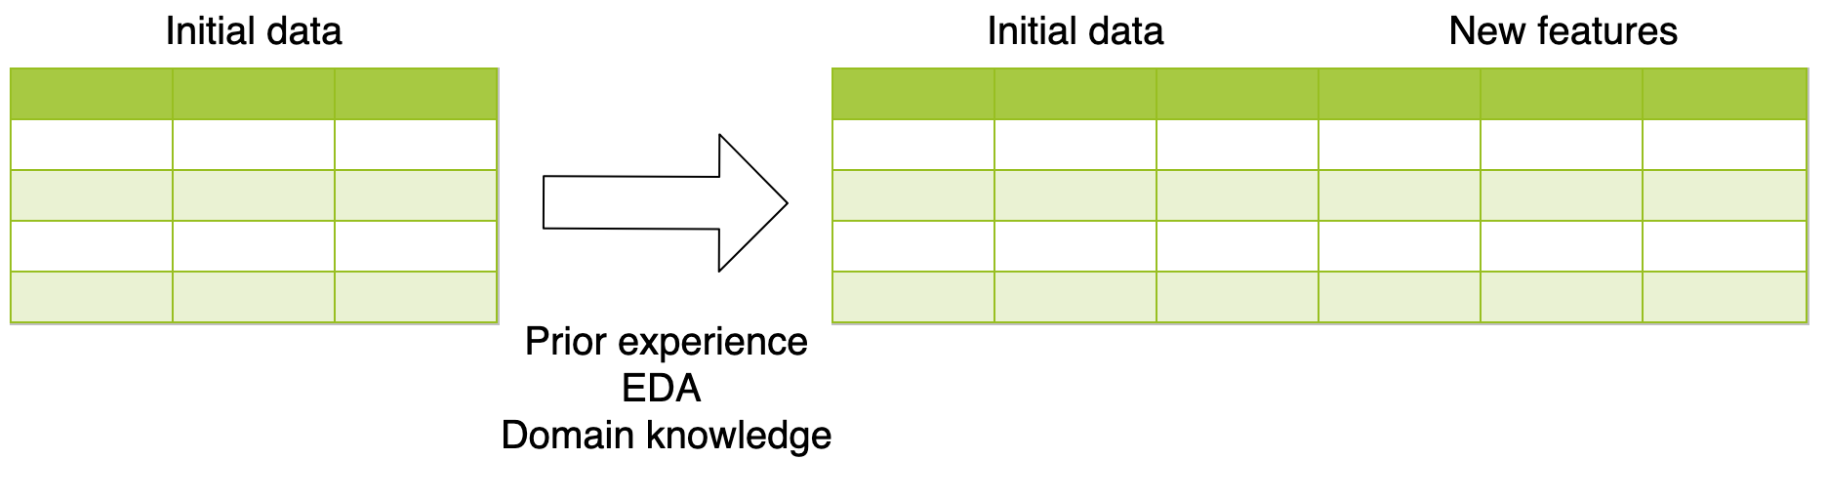

## **Creating Features**

E.g.
 - house price/ # bed rooms
 - bed rooms + bath rooms
 - date of week

In [ ]:
data = pd.concat([train, test])

# Some feature engineering processes ...

# Get the train and test back
train = data[data["id"].isin(train["id"])]
test = data[data["id"].isin(test["id"])]

### ***Exercise: Arithmetical features***

To practice creating new features, you will be working with a subsample from the Kaggle competition called "House Prices: Advanced Regression Techniques". The goal of this competition is to predict the price of the house based on its properties. It's a regression problem with Root Mean Squared Error as an evaluation metric.

Your goal is to create new features and determine whether they improve your validation score. To get the validation score from 5-fold cross-validation, you're given the `get_kfold_rmse()` function. Use it with the `train` DataFrame, available in your workspace, as an argument.

####### ***Instructions***
- Create a new feature representing the total area (basement, 1st and 2nd floors) of the house. The columns `"TotalBsmtSF"`, `"FirstFlrSF"` and `"SecondFlrSF"` give the areas of the basement, 1st and 2nd floors, respectively.
- Create a new feature representing the area of the garden. It is a difference between the total area of the property (`"LotArea"`) and the first floor area (`"FirstFlrSF"`).
- Create a new feature representing the total number of bathrooms in the house. It is a sum of full bathrooms ("`FullBath`") and half bathrooms ("`HalfBath`").

In [ ]:
def get_kfold_rmse(train):
    mse_scores = []

    for train_index, test_index in kf.split(train):
        train = train.fillna(0)
        feats = [x for x in train.columns if x not in ['Id', 'SalePrice', 'RoofStyle', 'CentralAir']]

        fold_train, fold_test = train.loc[train_index], train.loc[test_index]

        # Fit the data and make predictions
        # Create a Random Forest object
        rf = RandomForestRegressor(n_estimators=10, min_samples_split=10, random_state=123)

        # Train a model
        rf.fit(X=fold_train[feats], y=fold_train['SalePrice'])

        # Get predictions for the test set
        pred = rf.predict(fold_test[feats])

        fold_score = mean_squared_error(fold_test['SalePrice'], pred)
        mse_scores.append(np.sqrt(fold_score))

    return round(np.mean(mse_scores) + np.std(mse_scores), 2)

kf = KFold(n_splits=5, random_state=123, shuffle=True)
train = pd.read_csv("train.csv")
train = train[['Id', 'LotArea', 'OverallQual', 'YearBuilt', 'RoofStyle', 'TotalBsmtSF', 'CentralAir', '1stFlrSF', '2ndFlrSF', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea', 'SalePrice']]

In [ ]:
# Look at the initial RMSE
print('RMSE before feature engineering:', get_kfold_rmse(train))

# Find the total area of the house
train['TotalArea'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
print('RMSE with total area:', get_kfold_rmse(train))

# Find the area of the garden
train['GardenArea'] = train['LotArea'] - train['1stFlrSF']
print('RMSE with garden area:', get_kfold_rmse(train))

# Find total number of bathrooms
train['TotalBath'] = train['FullBath'] + train['HalfBath']
print('RMSE with number of bathrooms:', get_kfold_rmse(train))

RMSE before feature engineering: 36029.39
RMSE with total area: 35073.2
RMSE with garden area: 34413.55
RMSE with number of bathrooms: 34506.78


You've created three new features. Here you see that house area improved the RMSE by almost \$1,000. Adding garden area improved the RMSE by another $600. However, with the total number of bathrooms, the RMSE has increased. It means that you keep the new area features, but do not add `"TotalBath"` as a new feature. Let's now work with the datetime features.

### ***Exercise: Date features***

You've built some basic features using numerical variables. Now, it's time to create features based on date and time. You will practice on a subsample from the Taxi Fare Prediction Kaggle competition data. The data represents information about the taxi rides and the goal is to predict the price for each ride.

Your objective is to generate date features from the pickup datetime. Recall that it's better to create new features for train and test data simultaneously. After the features are created, split the data back into the train and test DataFrames. Here it's done using pandas' **`isin()`** method.

##### ***Instructions***

- Concatenate the `train` and `test` DataFrames into a single DataFrame `taxi`.
- Convert the "`pickup_datetime`" column to a datetime object.
- Create the day of week (using **`.dayofweek`** attribute) and hour (using .**`hour`** attribute) features from the "`pickup_datetime`" column.

In [ ]:
train = pd.read_csv("taxi_train_chapter_4.csv")
test = pd.read_csv("taxi_test_chapter_4.csv")

# Concatenate train and test together
taxi = pd.concat([train, test])

# Convert pickup date to datetime object
taxi['pickup_datetime'] = pd.to_datetime(taxi['pickup_datetime'])

# Create a day of week feature
taxi['dayofweek'] = taxi['pickup_datetime'].dt.dayofweek

# Create an hour feature
taxi['hour'] = taxi['pickup_datetime'].dt.hour

# Split back into train and test
new_train = taxi[taxi['id'].isin(train['id'])]
new_test = taxi[taxi['id'].isin(test['id'])]

# **Categorical Features**



## **Label Encoder**

- Not recommended to linear model
- Ok for tree base model

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['cat_encoded'] = le.fit_transform(df['cat'])

## **One-Hot Encoding**

In [ ]:
ohe = pd.get_dummies(df['cat'], prefix='ohe_cat')
df.drop('cat', axis=1, inplace=True)
df = pd.concat([df, ohe], axis=1)

## **Binary Features**

In [ ]:
le = LabelEncoder()
binary_feature['binary_encoded'] = le.fit_transform(binary_feature['binary'])

### ***Exercise: Label encoding***

Let's work on categorical variables encoding. You will again work with a subsample from the House Prices Kaggle competition.

Your objective is to encode categorical features `"RoofStyle"` and `"CentralAir"` using label encoding.

#### ***Instructions***

- Concatenate train and test DataFrames into a single DataFrame houses.
- Create a LabelEncoder object without arguments and assign it to le.
- Create new label-encoded features for "`RoofStyle`" and "`CentralAir`" using the same le object.

In [ ]:
from sklearn.preprocessing import LabelEncoder

train, test = pd.read_csv("train.csv"), pd.read_csv("test.csv")
train = train[['Id', 'LotArea', 'OverallQual', 'YearBuilt', 'RoofStyle', 'TotalBsmtSF', 'CentralAir', '1stFlrSF', '2ndFlrSF', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea', 'SalePrice']]
test = test[['Id', 'LotArea', 'OverallQual', 'YearBuilt', 'RoofStyle', 'TotalBsmtSF', 'CentralAir', '1stFlrSF', '2ndFlrSF', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea']]

# Concatenate train and test together
houses = pd.concat([train, test])

# Label encoder
le = LabelEncoder()

# Create new features
houses['RoofStyle_enc'] = le.fit_transform(houses['RoofStyle'])
houses['CentralAir_enc'] = le.fit_transform(houses[['CentralAir']])

# Look at new features
print(houses[['RoofStyle', 'RoofStyle_enc', 'CentralAir', 'CentralAir_enc']].head())

  RoofStyle  RoofStyle_enc CentralAir  CentralAir_enc
0     Gable              1          Y               1
1     Gable              1          Y               1
2     Gable              1          Y               1
3     Gable              1          Y               1
4     Gable              1          Y               1


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### ***Exercise: One-Hot encoding***

The problem with label encoding is that it implicitly assumes that there is a ranking dependency between the categories. So, let's change the encoding method for the features "`RoofStyle`" and "`CentralAir`" to one-hot encoding.

Recall that if you're dealing with binary features (categorical features with only two categories) it is suggested to apply label encoder only.

Your goal is to determine which of the mentioned features is not binary, and to apply one-hot encoding only to this one.

#### ***Instructions***

- Determine the distribution of "`RoofStyle`" and "`CentralAir`" features using pandas' **`value_counts()`** method.
- As long as "CentralAir" is a binary feature, encode it with a label encoder (0 - for one class and 1 - for another class).
- For the categorical feature `"RoofStyle"` let's use the one-hot encoder. Firstly, create one-hot encoded features using the `get_dummies()` method. Then they are concatenated to the initial houses DataFrame.


In [ ]:
# Concatenate train and test together
houses = pd.concat([train, test])

# Look at feature distributions
print(houses['RoofStyle'].value_counts(), '\n')
print(houses['CentralAir'].value_counts())

RoofStyle
Gable      2310
Hip         551
Gambrel      22
Flat         20
Mansard      11
Shed          5
Name: count, dtype: int64 

CentralAir
Y    2723
N     196
Name: count, dtype: int64


In [ ]:
# Concatenate train and test together
houses = pd.concat([train, test])

# Label encode binary 'CentralAir' feature
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
houses['CentralAir_enc'] = le.fit_transform(houses['CentralAir'])

# Create One-Hot encoded features
ohe = pd.get_dummies(houses['RoofStyle'], prefix='RoofStyle', dtype=int)

# Concatenate OHE features to houses
houses = pd.concat([houses, ohe], axis=1)

# Look at OHE features
print(houses[[col for col in houses.columns if 'RoofStyle' in col]].head(3))

  RoofStyle  RoofStyle_Flat  RoofStyle_Gable  RoofStyle_Gambrel  \
0     Gable               0                1                  0   
1     Gable               0                1                  0   
2     Gable               0                1                  0   

   RoofStyle_Hip  RoofStyle_Mansard  RoofStyle_Shed  
0              0                  0               0  
1              0                  0               0  
2              0                  0               0  


# **Target Encoding**

* is useful when we have too many categories in one or more categorical features.
* if we use one-hot encoding the number of features/ columns will explode.

## **Mean Target Encoding**

###### **Steps**:
1. Calculate mean on the `train` set and apply to the `test` set.
  - We can use the whole `train` set here.
2. To add mean target encoded into train, we need to split `train` into `K` folds.  Calculate mean on `K-1` folds and apply to `K`-th fold.
3. Add mean target encoded feature to the `train` set.


Below is the first step apply mean target encoding to the `test` set.  The example is ***binary classification***.

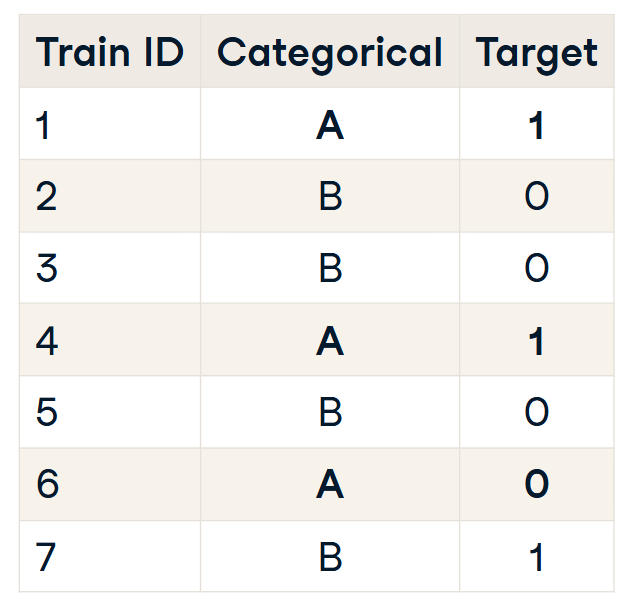

- Mean on A is `(1 + 1 + 0)/ 3`
- Mean on B is `(0 + 0 + 0 + 1)/ 4`

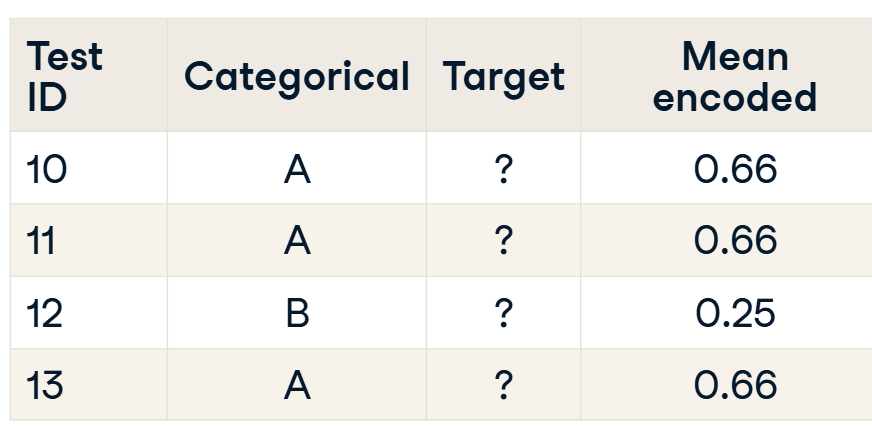

## **Train Encoding using `Out-of-Fold`**

This is step 2. from above.  If we do not use ***out-of-fold***, we are prone to data leakage and lead to overfitting.

For example below split data into 2 folds.

- Calculate the target mean of fold 1 using only observations from fold 2.
- Calculate the target mean of fold 2 using only observations from fold 1.

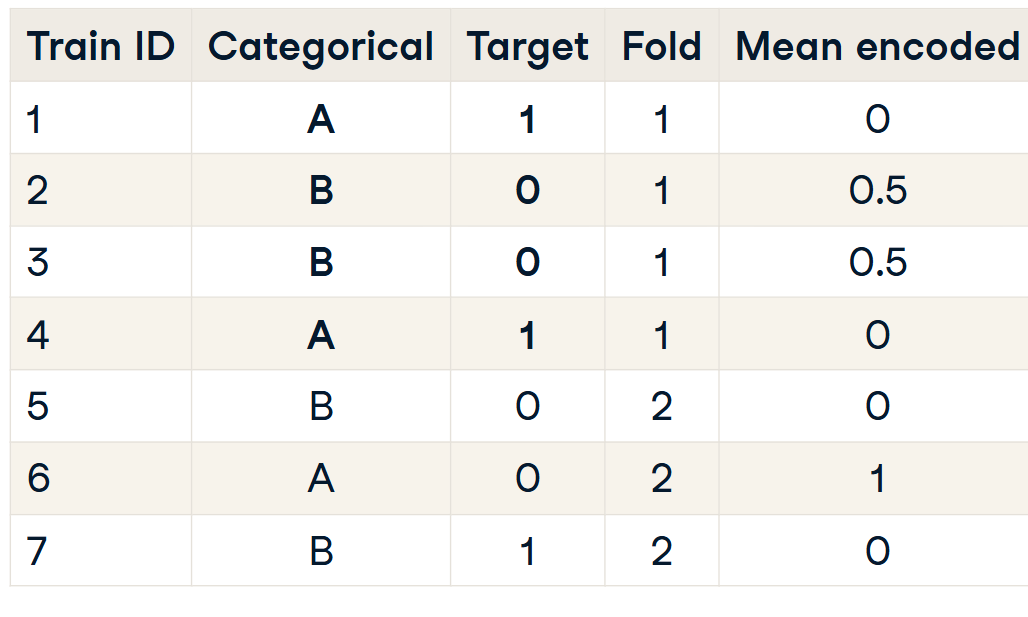

- We now have this mean target encoded feature in ***both*** `train` and `test` set.
- We can use this new feature instead of the old one in our model.

## **Smooth Mean Encoding**

- This is used to account for the case where we have some rare categories that may appear once or twice from a high number of categories in that categorical feature.

- This means we could get `0` or `1`, a perfect match, leading to overfitting.

$$\text{mean_enc}_i = \frac{\text{category_sum}_i}{n_i}$$

$$\text{smoothed_mean_encoding} = \frac{\text{category_sum}_i + \alpha \cdot \text{global_mean}}{n_i + \alpha}$$

$$5 \leq \alpha \leq 10, \text{ and } i \in \{A, B, C, D, \ldots\}$$

- If the category is large, we use $\text{smoothed_mean_enc}_i$.
- Otherwise we use global mean, e.g. category C appear once in the test set.

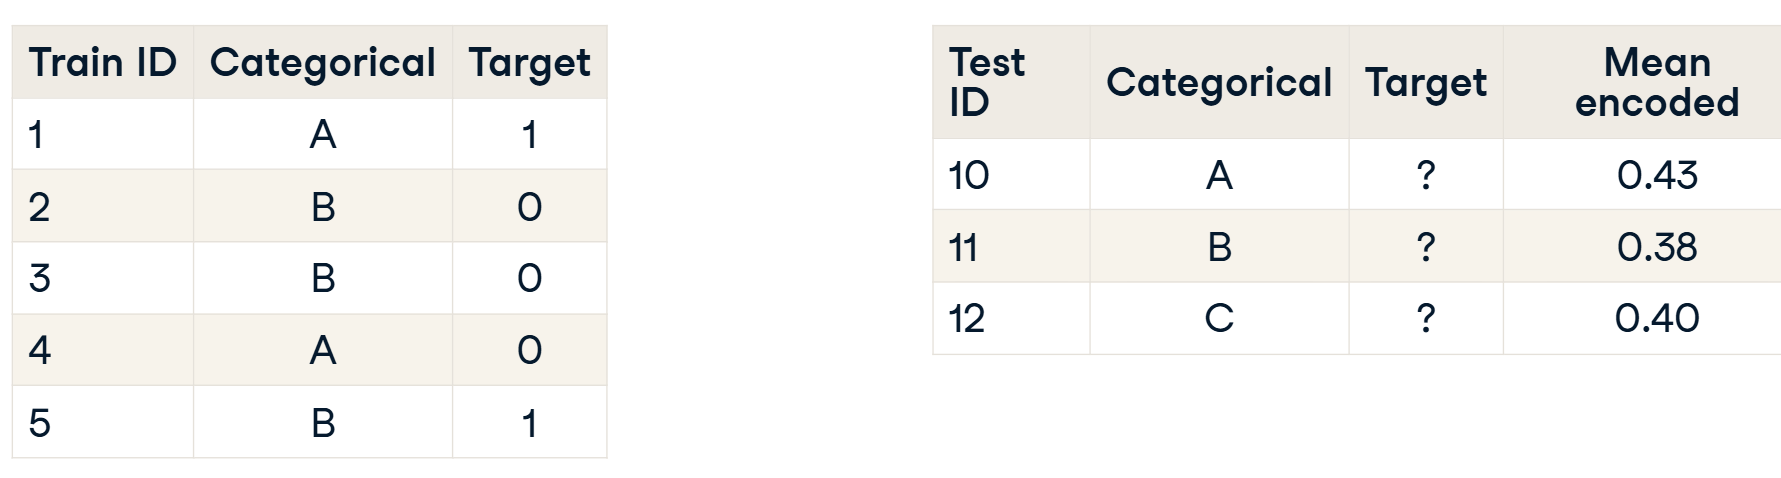

In [ ]:
# From the example above: Category A
category_sum_A = 1 + 0
n_A = 2
global_mean = (1 + 0 + 0 + 0 + 1)/ 5
α = 5

round((category_sum_A + α * global_mean)/ (n_A + α), 2)

0.43

In [ ]:
# Category B
category_sum_B = 0 + 0 + 1
n_B = 3
round((category_sum_B + α * global_mean)/ (n_B + α), 2)

0.38

### ***Exercise: Mean target encoding***

First of all, you will create a function that implements mean target encoding. Remember that you need to develop the two following steps:

1. Calculate the mean on the train, apply to the test
2. Split train into K folds. Calculate the out-of-fold mean for each fold, apply to this particular fold

Each of these steps will be implemented in a separate function: `test_mean_target_encoding()` and `train_mean_target_encoding()`, respectively.

The final function `mean_target_encoding()` takes as arguments:
  - the `train` and `test` DataFrames,
  - the name of the categorical column to be encoded,
  - the name of the target column and
  - a smoothing parameter alpha.
  
It returns two values: a new feature for `train` and `test` DataFrames, respectively.

#### ***Instructions***

- You need to add smoothing to avoid overfitting. So, add $\alpha$
 parameter to the denominator in `train_statistics` calculations.
- You need to treat new categories in the test data. So, pass a global mean as an argument to the **`fillna()`** method.

In [ ]:
# Small example to demonstrate the process of the below functions

train = pd.DataFrame(data={'category':['A', 'A', 'B', 'B', 'B', 'C'], 'target':[0, 1, 1, 1, 1, 0], 'sales': [100, 200, 50, 75, 80, 99]})
categorical, target = 'category', 'target'
train_groups = train.groupby(categorical)
category_sum = train_groups[target].sum()
category_size = train_groups.size()
alpha = 5

train_statistics = (category_sum + global_mean * alpha) / (category_size + alpha)
print(train_statistics)


category
A    0.428571
B    0.625000
C    0.333333
dtype: float64


In [ ]:
def test_mean_target_encoding(train, test, target, categorical, alpha=5):
    # Calculate global mean on the train data
    global_mean = train[target].mean()

    # Group by the categorical feature and calculate its properties
    train_groups = train.groupby(categorical)
    category_sum = train_groups[target].sum()
    category_size = train_groups.size()

    # Calculate smoothed mean target statistics
    train_statistics = (category_sum + global_mean * alpha) / (category_size + alpha)

    # Apply statistics to the test data and fill new categories with global mean
    test_feature = test[categorical].map(train_statistics).fillna(global_mean)
    return test_feature.values

- To calculate the `train` mean encoded feature you need to use ***out-of-fold*** statistics, splitting `train` into several folds. Specify the `train` and `test` indices for each validation split to access it.


In [ ]:
train

,category,target,sales
0,A,0,100
1,A,1,200
2,B,1,50
3,B,1,75
4,B,1,80
5,C,0,99


In [ ]:
def train_mean_target_encoding(train, target, categorical, alpha=5):
    # Create 5-fold cross-validation
    kf = KFold(n_splits=5, random_state=123, shuffle=True)
    train_feature = pd.Series(index=train.index)

    # For each folds split
    for train_index, test_index in kf.split(train):
        cv_train, cv_test = train.iloc[train_index], train.iloc[test_index]

        # Calculate out-of-fold statistics and apply to cv_test
        cv_test_feature = test_mean_target_encoding(cv_train, cv_test, target, categorical, alpha)

        # Save new feature for this particular fold
        train_feature.iloc[test_index] = cv_test_feature
    return train_feature.values

- Finally, you just calculate `train` and `test` target mean encoded features and return them from the function. So, return `train_feature` and `test_feature` obtained.

In [ ]:
def mean_target_encoding(train, test, target, categorical, alpha=5):

    # Get the train feature
    train_feature = train_mean_target_encoding(train, target, categorical, alpha)

    # Get the test feature
    test_feature = test_mean_target_encoding(train, test, target, categorical, alpha)

    # Return new features to add to the model
    return train_feature, test_feature

Now you are equipped with a function that performs mean target encoding of any categorical feature. Move on to learn how to implement mean target encoding for the K-fold cross-validation using the `mean_target_encoding()` function you've just built.

### ***Exercise: K-fold cross-validation***

*จริงๆ เอาไปใช้กับทั้งข้อมูลได้เลย ไม่ใช่ใช้ได้แค่ใน Cross Validation*

You will work with a binary classification problem on a subsample from Kaggle playground competition. The objective of this competition is to predict whether a famous basketball player Kobe Bryant scored a basket or missed a particular shot.

`Train` data is available in your workspace as `bryant_shots` DataFrame. It contains data on 10,000 shots with its properties and a target variable `"shot_made_flag"` -- whether shot was scored or not.

One of the features in the data is `"game_id"` -- a particular game where the shot was made. There are 541 distinct games. So, you deal with a high-cardinality categorical feature. Let's encode it using a target mean!

Suppose you're using 5-fold cross-validation and want to evaluate a mean target encoded feature on the local validation.

#### ***Instructions***

* To achieve this, you need to repeat encoding procedure for the `"game_id"` categorical feature inside each folds split separately. Your goal is to specify all the missing parameters for the `mean_target_encoding()` function call inside each folds split.
- Recall that the `train` and `test` parameters expect the `train` and `test` DataFrames.
-  The `target` and `categorical` parameters expect names of the target variable and categorical feature to be encoded.


In [ ]:
bryant_shots = pd.read_csv('data.csv')
bryant_shots = bryant_shots[['shot_id', 'game_id','lat', 'lon', 'minutes_remaining', 'playoffs', 'season', 'shot_distance', 'shot_type', 'shot_made_flag']]
bryant_shots = bryant_shots.dropna()

# Create 5-fold cross-validation
kf = KFold(n_splits=5, random_state=123, shuffle=True)

# For each folds split
for train_index, test_index in kf.split(bryant_shots):
    cv_train, cv_test = bryant_shots.iloc[train_index], bryant_shots.iloc[test_index]

    # Create mean target encoded feature
    cv_train['game_id_enc'], cv_test['game_id_enc'] = mean_target_encoding(train=cv_train,
                                                                           test=cv_test,
                                                                           target='shot_made_flag',
                                                                           categorical="game_id",
                                                                           alpha=5)
    # Look at the encoding
    print(cv_train[['game_id', 'shot_made_flag', 'game_id_enc']].head(n=1))

    game_id  shot_made_flag  game_id_enc
1  20000012             0.0     0.567997
    game_id  shot_made_flag  game_id_enc
1  20000012             0.0     0.473716
    game_id  shot_made_flag  game_id_enc
1  20000012             0.0     0.565248
    game_id  shot_made_flag  game_id_enc
2  20000012             1.0     0.403926
    game_id  shot_made_flag  game_id_enc
1  20000012             0.0     0.323415


/tmp/ipykernel_1207/2187368787.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cv_train['game_id_enc'], cv_test['game_id_enc'] = mean_target_encoding(train=cv_train, test=cv_test, target='shot_made_flag', categorical="game_id",alpha=5)
/tmp/ipykernel_1207/2187368787.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cv_train['game_id_enc'], cv_test['game_id_enc'] = mean_target_encoding(train=cv_train, test=cv_test, target='shot_made_flag', categorical="game_id",alpha=5)
/tmp/ipykernel_1207/2187368787

You could see different game encodings for each validation split in the output. The main conclusion you should make: while using local cross-validation, you need to repeat mean target encoding procedure inside each folds split separately. Go on to try other problem types beyond binary classification!



### ***Exercise: Beyond binary classification***

Of course, binary classification is just a single special case. Target encoding could be applied to any target variable type:

- For **binary classification**, mean target encoding is commonly used
- For **regression**, mean could be changed to median, quartiles, etc.
- For **multi-class classification** with *N* classes we create *N* features with target mean for each category in one vs. all fashion

The `mean_target_encoding()` function you've created could be used for any target type specified above. Let's apply it for the regression problem on the example of *House Prices Kaggle competition*.



Your goal is to encode a categorical feature `"RoofStyle"` using mean target encoding.

##### ***Instructions***

- Specify all the missing parameters for the `mean_target_encoding()` function call. Target variable name is `"SalePrice"`. Set $\alpha$ hyperparameter to 10.
- Recall that the `train` and `test` parameters expect the `train` and `test` DataFrames.
- While the `target` and `categorical` parameters expect names of the target variable and feature to be encoded.

In [ ]:
def mean_target_encoding(train, test, target, categorical, alpha=5):

    # Get test feature
    test_feature = test_mean_target_encoding(train, test, target, categorical, alpha)

    # Get train feature
    train_feature = train_mean_target_encoding(train, target, categorical, alpha)

    # Return new features to add to the model
    return train_feature, test_feature

In [ ]:
train, test = pd.read_csv("train.csv"), pd.read_csv("test.csv")
train = train[['Id', 'LotArea', 'OverallQual', 'YearBuilt', 'RoofStyle', 'TotalBsmtSF', 'CentralAir', '1stFlrSF', '2ndFlrSF', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea', 'SalePrice']]
test = test[['Id', 'LotArea', 'OverallQual', 'YearBuilt', 'RoofStyle', 'TotalBsmtSF', 'CentralAir', '1stFlrSF', '2ndFlrSF', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea']]

# Create mean target encoded feature
train['RoofStyle_enc'], test['RoofStyle_enc'] = mean_target_encoding(train=train,
                                                                     test=test,
                                                                     target='SalePrice',
                                                                     categorical='RoofStyle',
                                                                     alpha=10)

# Look at the encoding
print(test[['RoofStyle', 'RoofStyle_enc']].drop_duplicates())

     RoofStyle  RoofStyle_enc
0        Gable  171565.947836
1          Hip  217594.645131
98     Gambrel  164152.950424
133       Flat  188703.563431
362    Mansard  180775.938759
1053      Shed  188267.663242


So, you observe that houses with the `Hip` roof are the most pricy, while houses with the `Gambrel` roof are the cheapest. It's exactly the goal of ***target encoding***: you've encoded categorical feature in such a manner that there is now a correlation between category values and target variable. We're done with categorical encoders. Now it's time to talk about the missing data.

# **Missing Data**

## **Missing numerical data**

- Mean/ median imputation
   - this just assigns average observation to the missing values so we lose the information that this value was actually missing.

- Constant value imputation (DON'T use this on linear models.  Use it on ***Tree-based*** models)
   - this reflects that the value is missing
      - e.g. `-999`

## **Missing categorical data**
- Most frequent category imputation
- New category imputation e.g. `'MISS'`

## **Find missing data**

- **`df.isnull()`**
- **`df.isnull().sum()`**

In [ ]:
from sklearn.impute import SimpleImputer

# Numerical
mean_imputer = SimpleImputer(strategy='mean')
constant_imputer = SimpleImputer(strategy='constant', fill_value=-999)
df[['column_with_missing']] = mean_imputer.fit_transform(df[['columns_with_missing']])

# Catrgorical
frequent_imputer = SimpleImputer(strategy='most_frequent')
constant_imputer = SimpleImputer(strategy='constant', fill_value='MISS')

# **Local validation**

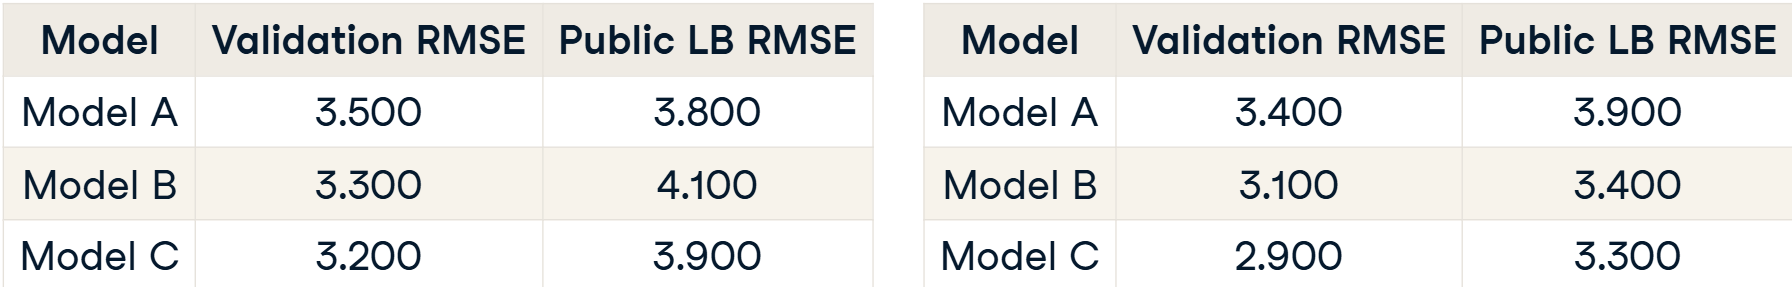!

- If local validation improves but the public validation does not (e.g. the left table), it means your strategy may not work.
- If both local validation and public validation improves, it means you come to the right track.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

taxi_train, taxi_test = pd.read_csv('taxi_train_chapter_4.csv'), pd.read_csv('/content/taxi_test_chapter_4.csv')
validation_train, validation_test = train_test_split(taxi_train, test_size=0.3, random_state=123)
features = ['pickup_longitude',  'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']

# Baseline model
gb = GradientBoostingRegressor()
X_train, y_train = taxi_train[features], taxi_train['fare_amount']
X_test = taxi_test[features]
gb.fit(X_train, y_train)
taxi_test['fare_amount'] = gb.predict(X_test)
taxi_test[['id', 'fare_amount']].to_csv('submission.csv', index=False)

### ***Exercise: Replicate validation score***

You've seen both validation and Public Leaderboard scores above. However, the code examples are available only for the test data. To get the validation scores you have to repeat the same process on the holdout set.

The first goal is to evaluate the Baseline model on the validation data. You will replicate the simplest Baseline based on the mean of `"fare_amount"`. Recall that as a validation strategy we used a 30% holdout split with `validation_train` as train and `validation_test` as holdout DataFrames.

#### ***Instructions***

- Calculate the mean of `"fare_amount"` over the whole `validation_train` DataFrame.
- Assign this naive prediction value to all the holdout predictions. Store them in the `"pred"` column.


In [ ]:
# Calculate the mean fare_amount on the validation_train data
naive_prediction = np.mean(validation_train['fare_amount'])

# Assign naive prediction to all the holdout observations
validation_test['pred'] = naive_prediction

# Measure the local RMSE
rmse = sqrt(mean_squared_error(validation_test['fare_amount'], validation_test['pred']))
print('Validation RMSE for Baseline I model: {:.3f}'.format(rmse))

Validation RMSE for Baseline I model: 9.986


### ***Exercise: Baseline based on the date***

Let's build a model whose predictions are based on grouping variables. It's clear that the ride fare could depend on the part of the day. For example, prices could be higher during the rush hours.

Your goal is to build a baseline model that will assign the average `"fare_amount"` for the corresponding hour. For now, you will create the model for the whole train data and make predictions for the test dataset.


###### ***Instructions***

- Get the hour from the `"pickup_datetime"` column for the `train` and `test` DataFrames.
- Calculate the mean `"fare_amount"` for each hour on the train data.
- Make test predictions using pandas' **`map()`** method and the grouping obtained.
- Write predictions to the file.

In [ ]:
train, test = pd.read_csv('taxi_train_chapter_4.csv', parse_dates=['pickup_datetime']), pd.read_csv('taxi_test_chapter_4.csv', parse_dates=['pickup_datetime'])

# Get pickup hour from the pickup_datetime column
train['hour'] = train['pickup_datetime'].dt.hour
test['hour'] = test['pickup_datetime'].dt.hour

# Calculate average fare_amount grouped by pickup hour
hour_groups = train.groupby('hour')['fare_amount'].mean()

# Make predictions on the test set
test['fare_amount'] = test['hour'].map(hour_groups)

# Write predictions
test[['id','fare_amount']].to_csv('hour_mean_sub.csv', index=False)

#### ***Supplementary Exercise: Calculate RMSE for group statistics***

In [ ]:
taxi_train, taxi_test = pd.read_csv('taxi_train_chapter_4.csv', parse_dates=['pickup_datetime']), pd.read_csv('/content/taxi_test_chapter_4.csv', parse_dates=['pickup_datetime'])
validation_train, validation_test = train_test_split(taxi_train, test_size=0.3, random_state=123)
features = ['pickup_longitude',  'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']
validation_train['hour'] = validation_train['pickup_datetime'].dt.hour
validation_test['hour'] = validation_test['pickup_datetime'].dt.hour
hour_groups = validation_train.groupby('hour')['fare_amount'].mean()
validation_test['pred'] = validation_test['hour'].map(hour_groups)
rmse = sqrt(mean_squared_error(validation_test['fare_amount'], validation_test['pred']))
print('Validation RMSE for Baseline I model: {:.3f}'.format(rmse))

Validation RMSE for Baseline I model: 9.985


The RMSE from the supplementary exercise shows that it is similar to constant prediction.

### ***Exercise: Baseline based on the gradient boosting***

Let's build a final baseline based on the **Random Forest**.

The goal of this exercise is to take numeric features and train a Random Forest model without any tuning. After that, you could make test predictions and validate the result on the Public Leaderboard. Note that you've already got an `"hour"` feature which could also be used as an input to the model.

##### ***Instructions***

- Add the `"hour"` feature to the list of numeric `features`.
- Fit the **`RandomForestRegressor`** on the `train` data with numeric `features` and `"fare_amount"` as a target.
- Use the trained Random Forest model to make predictions on the test data.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Select only numeric features
features = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
            'dropoff_latitude', 'passenger_count', 'hour']

# Train a Random Forest model
rf = RandomForestRegressor()
rf.fit(train[features], train.fare_amount)

# Make predictions on the test data
test['fare_amount'] = rf.predict(test[features])

# Write predictions
test[['id','fare_amount']].to_csv('rf_sub.csv', index=False)

##### ***Supplementary Exercise: Compute RMSE***

In [ ]:
features = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
            'dropoff_latitude', 'passenger_count', 'hour']

rf = RandomForestRegressor()
rf.fit(validation_train[features], validation_train['fare_amount'])
validation_test['pred'] = rf.predict(validation_test[features])
rmse = sqrt(mean_squared_error(validation_test['fare_amount'], validation_test['pred']))
print('Validation RMSE for Random Forest: {:.3f}'.format(rmse))

Validation RMSE for Random Forest: 5.485


# **Hyperparameter Tuning**

### **Linear Regression**

$$Loss = \sum_{i=1}^N(y_i - \hat{y}_i)^2$$

### **Ridge Regression**
- adding penalty on coefficients' sizes

$$Loss = \sum_{i=1}^N (y_i - \hat{y}_i)^2 + \alpha\sum_{j=1}^Kw_j^2$$

## **Hyperparameter Optimization Strategies**

- **Grid Search**
- **Random Search**
- **Bayesian Optimization**
  - use past parameter results to decide the next hyperparameter value to evaluate

## **Grid Search**

In [ ]:
from sklearn.linear_model import Ridge

αs = [0.01, 0.1, 1, 10]
results = {}

for α in αs:
    ridge = Ridge(alpha=α)
    results[α] = validation_score

### ***Exercise: Grid search***

Your goal now is to find the best `max_depth` hyperparameter value for the Gradient Boosting model. This hyperparameter limits the number of nodes in each individual tree. You will be using K-fold cross-validation to measure the local performance of the model for each hyperparameter value.

You're given a function `get_cv_score()`, which takes the `train` dataset and dictionary of the model parameters as arguments and returns the overall validation RMSE score over 3-fold cross-validation.

##### ***Instructions***

- Specify the grid for possible `max_depth` values with 3, 6, 9, 12 and 15.
- Pass each hyperparameter candidate in the grid to the model `params` dictionary.

In [ ]:
def get_cv_score(train, params):
    # Create KFold object
    kf = KFold(n_splits=3, shuffle=True, random_state=123)

    rmse_scores = []

    # Loop through each split
    for train_index, test_index in kf.split(train):
        cv_train, cv_test = train.iloc[train_index], train.iloc[test_index]

        # Train a Gradient Boosting model
        gb = GradientBoostingRegressor(random_state=123, **params).fit(cv_train[features], cv_train.fare_amount)

        # Make predictions on the test data
        pred = gb.predict(cv_test[features])

        fold_score = np.sqrt(mean_squared_error(cv_test['fare_amount'], pred))
        rmse_scores.append(fold_score)

    return np.round(np.mean(rmse_scores) + np.std(rmse_scores), 5)

features = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'hour']
train, test = pd.read_csv('taxi_train_chapter_4.csv', parse_dates=['pickup_datetime']), pd.read_csv('taxi_test_chapter_4.csv', parse_dates=['pickup_datetime'])
train['hour'] = train['pickup_datetime'].dt.hour
test['hour'] = test['pickup_datetime'].dt.hour

In [ ]:
# Possible max depth values
max_depth_grid = [3, 6, 9, 12, 15]
results = {}

# For each value in the grid
for max_depth_candidate in max_depth_grid:
    # Specify parameters for the model
    params = {'max_depth': max_depth_candidate}

    # Calculate validation score for a particular hyperparameter
    validation_score = get_cv_score(train, params)

    # Save the results for each max depth value
    results[max_depth_candidate] = validation_score
print(results)

{3: np.float64(5.67296), 6: np.float64(5.36925), 9: np.float64(5.35641), 12: np.float64(5.49932), 15: np.float64(5.70246)}


We have a validation score for each value in the grid. It's clear that the optimal max depth value is located somewhere between 3 and 6. The next step could be to use a smaller grid, for example [3, 4, 5, 6] and repeat the same process. Moving from larger to smaller grids allows us to find the most optimal values. Keep going to try optimizing 2 hyperparameters simultaneously.

### ***Exercise: 2D grid search***

The drawback of tuning each hyperparameter independently is a potential dependency between different hyperparameters. The better approach is to try all the possible hyperparameter combinations. However, in such cases, the grid search space is rapidly expanding. For example, if we have 2 parameters with 10 possible values, it will yield 100 experiment runs.

Your goal is to find the best hyperparameter couple of `max_depth` and `subsample` for the Gradient Boosting model. `subsample` is a fraction of observations to be used for fitting the individual trees.

You're given a function `get_cv_score()`, which takes the `train` dataset and dictionary of the model parameters as arguments and returns the overall validation RMSE score over 3-fold cross-validation.

##### ***Instructions***

- Specify the grids for possible `max_depth` and `subsample` values.
  - For `max_depth`: 3, 5 and 7.
  - For `subsample`: 0.8, 0.9 and 1.0.
- Apply the `product()` function from the `itertools` package to the hyperparameter grids. It returns all possible combinations for these two grids.
Pass each hyperparameters candidate couple to the model `params` dictionary.

In [ ]:
# Hyperparameter grids
max_depth_grid = [3, 5, 7]
subsample_grid = [0.8, 0.9, 1.0]
results = {}

# For each couple in the grid
for max_depth_candidate, subsample_candidate in itertools.product(max_depth_grid, subsample_grid):
    params = {'max_depth': max_depth_candidate,
              'subsample': subsample_candidate}
    validation_score = get_cv_score(train, params)
    # Save the results for each couple
    results[(max_depth_candidate, subsample_candidate)] = validation_score
print(results)

{(3, 0.8): np.float64(5.65813), (3, 0.9): np.float64(5.65228), (3, 1.0): np.float64(5.67296), (5, 0.8): np.float64(5.34947), (5, 0.9): np.float64(5.44506), (5, 1.0): np.float64(5.3132), (7, 0.8): np.float64(5.38994), (7, 0.9): np.float64(5.40631), (7, 1.0): np.float64(5.3591)}


Tuning multiple hyperparameters simultaneously achieves better results.  However, do not spend too much time on the hyperparameter tuning at the beginning. Another approach that almost always improves your solution is model ensembling.

# **Ensemble**

## **Model blending**

- Make predictions on separate models
- Take their arithmetic mean (regression problem) or geometric mean (classification problem)

## **Model stacking**

1. Split train data into two parts
2. Train multiple models on part 1
3. Make predictions on part 2
4. Make predictions on test data
5. Train a new model on part 2 using predictions as features
6. Make predictions on the test data using the 2nd level model

## **Stacking example**

- Train models A, B, C on part 1.
- Make predictions on part 2.
- Make predictions on test data

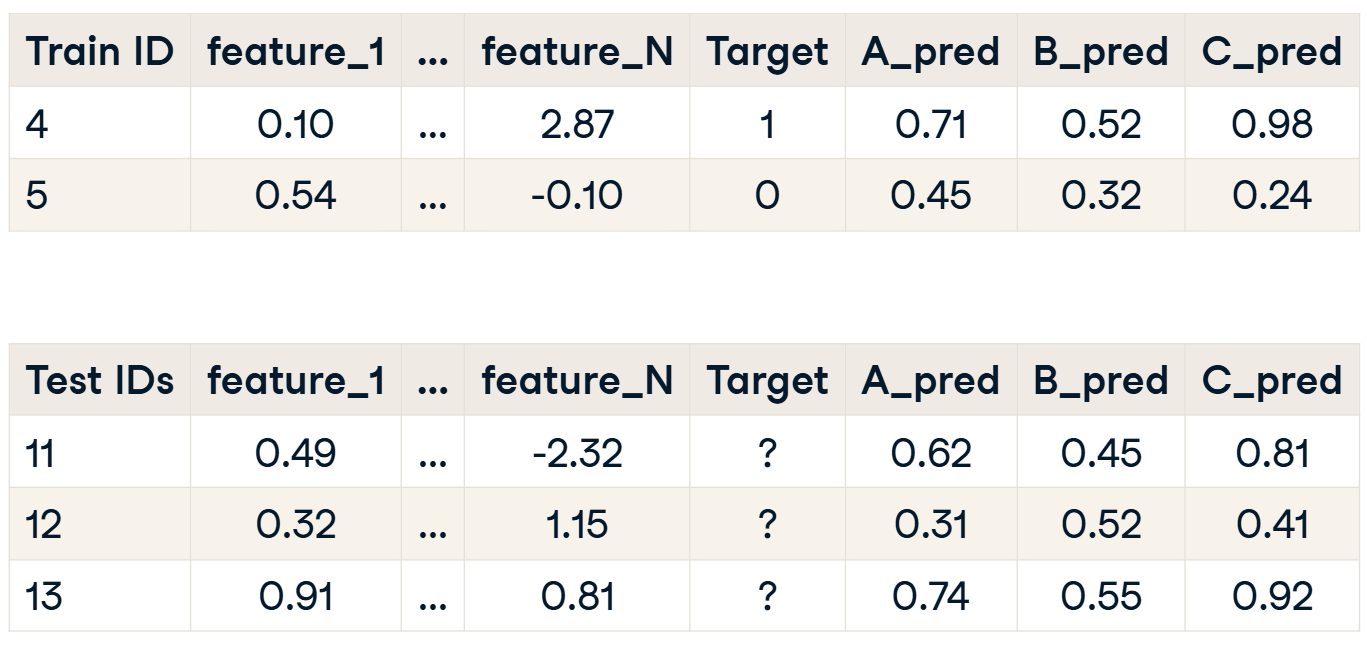

- Train 2nd level model on part 2
- Use this to make predictions on test data

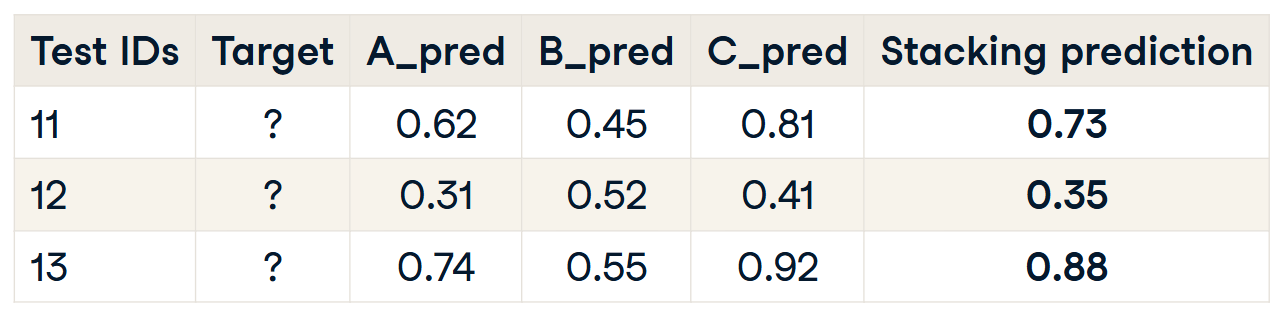

### ***Exercise: Model blending***

You will start creating model ensembles with a blending technique.

Your goal is to train 2 different models on the New York City Taxi competition data. Make predictions on the test data and then blend them using a simple arithmetic mean.

The `train` and `test` DataFrames are already available in your workspace. `features` is a list of columns to be used for training and it is also available in your workspace. The target variable name is `"fare_amount"`.

##### ***Instructions***

- Train a Gradient Boosting model on the train data using `features` list, and the `"fare_amount"` column as a target variable.
- Train a Random Forest model in the same manner.
- Make predictions on the test data using both Gradient Boosting and Random Forest models.
- Find the average of both models predictions.

In [29]:
train.head()

,id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour
0,0,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,17
1,1,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1,16
2,2,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2,0
3,3,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1,4
4,4,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1,7


In [30]:
features = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'hour']
train, test = pd.read_csv('taxi_train_chapter_4.csv', parse_dates=['pickup_datetime']), pd.read_csv('taxi_test_chapter_4.csv', parse_dates=['pickup_datetime'])
train['hour'] = train['pickup_datetime'].dt.hour
test['hour'] = test['pickup_datetime'].dt.hour

In [31]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

# Train a Gradient Boosting model
gb = GradientBoostingRegressor().fit(train[features], train.fare_amount)

# Train a Random Forest model
rf = RandomForestRegressor().fit(train[features], train.fare_amount)

# Make predictions on the test data
test['gb_pred'] = gb.predict(test[features])
test['rf_pred'] = rf.predict(test[features])

# Find mean of model predictions
test['blend'] = (test['gb_pred'] + test['rf_pred']) / 2
print(test[['gb_pred', 'rf_pred', 'blend']].head(3))

    gb_pred  rf_pred     blend
0  8.084739    8.974  8.529369
1  8.758979    8.504  8.631489
2  8.084739    5.508  6.796369


### ***Exercise: Model stacking I***

Now it's time for stacking.

1. Split train data into two parts
2. Train multiple models on Part 1
3. Make predictions on Part 2
4. Make predictions on the test data
5. Train a new model on Part 2 using predictions on Part 2 as sole features
6. Make predictions on the test data using the 2nd level model

`train` and `test` DataFrames are already available in your workspace. `features` is a list of columns to be used for training on the Part 1 data and it is also available in your workspace. Target variable name is `"fare_amount"`.

##### ***Instructions***

- Split the `train` DataFrame into two equal parts: `part_1` and `part_2`. Use the **`train_test_split()`** function with `test_size` equal to `0.5`.
-  Train Gradient Boosting and Random Forest models on the `part_1` data.


In [32]:
# Split train data into two parts
part_1, part_2 = train_test_split(train, test_size=0.5, random_state=123)

# Train a Gradient Boosting model on Part 1
gb = GradientBoostingRegressor().fit(part_1[features], part_1['fare_amount'])

# Train a Random Forest model on Part 1
rf = RandomForestRegressor().fit(part_1[features], part_1['fare_amount'])

- Make Gradient Boosting and Random Forest predictions on the `part_2` data.
- Make Gradient Boosting and Random Forest predictions on the `test` data.

In [33]:
# Make predictions on the Part 2 data
part_2['gb_pred'] = gb.predict(part_2[features])
part_2['rf_pred'] = rf.predict(part_2[features])

# Make predictions on the test data
test['gb_pred'] = gb.predict(test[features])
test['rf_pred'] = rf.predict(test[features])

The only steps left is to create a new model on Part 2 data using predictions as features and apply it to the test data.

### ***Exercise: Model stacking II***

OK, what you've done so far in the stacking implementation:

1. Split train data into two parts
2. Train multiple models on Part 1
3. Make predictions on Part 2
4. Make predictions on the test data

Now, your goal is to create a second level model *using predictions from steps 3 and 4 as features*. So, this model is trained on Part 2 data and then you can make stacking predictions on the test data.

`part_2` and `test` DataFrames are already available in your workspace. Gradient Boosting and Random Forest predictions are stored in these DataFrames under the names `"gb_pred"` and `"rf_pred"`, respectively.

#### ***Instructions***

- Train a Linear Regression model on the Part 2 data using Gradient Boosting and Random Forest models predictions as features.
- Make predictions on the test data using Gradient Boosting and Random Forest models predictions as features.

In [34]:
from sklearn.linear_model import LinearRegression

# Create linear regression model without the intercept
lr = LinearRegression(fit_intercept=False)

# Train 2nd level model on the Part 2 data
lr.fit(part_2[['gb_pred', 'rf_pred']], part_2['fare_amount'])

# Make stacking predictions on the test data
test['stacking'] = lr.predict(test[['gb_pred', 'rf_pred']])

# Look at the model coefficients
print(lr.coef_)

[0.21804706 0.78191829]


Usually, the 2nd level model is some simple model like Linear or Logistic Regressions. Also, note that you were NOT USING INTERCEPT in the Linear Regression just to combine pure model predictions. Looking at the coefficients, it's clear that 2nd level model has more trust to the Random Forest: 0.78 versus 0.21 for the Gradient Boost model.

(Results differ from datacamp since we do not have `'distance_km'` as one of the features.)

### ***Exercise: Testing Kaggle forum ideas***

Unfortunately, not all the Forum posts and Kernels are necessarily useful for your model. So instead of blindly incorporating ideas into your pipeline, you should test them first.

You're given a function `get_cv_score()`, which takes a `train` dataset as an argument and returns the overall validation root mean squared error over 3-fold cross-validation. The `train` DataFrame is already available in your workspace.

You should try different suggestions from the Kaggle Forum and check whether they improve your validation score.

##### ***Instructions***

- **Suggestion 1**: the `passenger_count` feature is useless. Let's see! Drop this feature and compare the scores.

In [35]:
def get_cv_score(train):
    features = ['pickup_longitude', 'pickup_latitude',
            'dropoff_longitude', 'dropoff_latitude',
            'passenger_count', 'distance_km', 'hour', 'weird_feature']

    features = [x for x in features if x in train.columns]

    # Create KFold object
    kf = KFold(n_splits=3, shuffle=True, random_state=123)

    rmse_scores = []

    # Loop through each split
    for train_index, test_index in kf.split(train):
        cv_train, cv_test = train.iloc[train_index], train.iloc[test_index]

        # Train a Gradient Boosting model
        gb = GradientBoostingRegressor(random_state=123).fit(cv_train[features], cv_train.fare_amount)

        # Make predictions on the test data
        pred = gb.predict(cv_test[features])

        fold_score = np.sqrt(mean_squared_error(cv_test['fare_amount'], pred))
        rmse_scores.append(fold_score)

    return np.round(np.mean(rmse_scores) + np.std(rmse_scores), 5)

In [36]:
# Drop passenger_count column
new_train_1 = train.drop('passenger_count', axis=1)

# Compare validation scores
initial_score = get_cv_score(train)
new_score = get_cv_score(new_train_1)

print('Initial score is {} and the new score is {}'.format(initial_score, new_score))

Initial score is 5.67296 and the new score is 5.63974


- This first suggestion worked. **Suggestion 2**: Sum of `pickup_latitude` and `distance_km` is a good feature. (Unfortunately we do not have `distance_km`.)

In [ ]:
# Create copy of the initial train DataFrame
new_train_2 = train.copy()

# Find sum of pickup latitude and ride distance
new_train_2['weird_feature'] = new_train_2['pickup_latitude'] + new_train_2['distance_km']

# Compare validation scores
initial_score = get_cv_score(train)
new_score = get_cv_score(new_train_2)

print('Initial score is {} and the new score is {}'.format(initial_score, new_score))

Be aware that not all the ideas shared publicly could work for you! In this particular case, dropping the `"passenger_count"` feature helped, while finding the sum of pickup latitude and ride distance did not.